In [1]:
import pandas as pd
import numpy as np
import math

import os, sys
import pickle

from matplotlib import pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import plotly.graph_objects as go

import lifelines
from lifelines.utils import concordance_index
from lifelines.statistics import logrank_test
from sksurv.util import Surv
from sksurv.metrics import concordance_index_ipcw

import tensorflow as tf
import tensorflow_probability as tfp

config = tf.compat.v1.ConfigProto()
config.gpu_options.allow_growth = True
sess = tf.compat.v1.Session(config = config)

from tensorflow import keras
from tensorflow.keras import optimizers, initializers, regularizers, layers

import scipy.stats as stats
from scipy.stats import norm, t, probplot, pearsonr, spearmanr, rankdata
from scipy.stats import truncnorm as truncnorm_scipy
from scipy.stats import gamma as gamma_dist
from scipy.special import gamma

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, KFold

import thetaflow as thf

import json
import gc
import glob
from pathlib import Path

sys.path.append("../")
import gndr_utils as utils

import pyarrow.parquet as pq

# Access metadata without loading data
# metadata_train = pq.read_metadata('../Cross Validation Data/train_data_small.parquet')
# metadata_test = pq.read_metadata('../Cross Validation Data/test_data_small.parquet')
metadata_train = pq.read_metadata('../train_data.parquet')
metadata_val = pq.read_metadata('../val_data.parquet')
metadata_test = pq.read_metadata('../test_data.parquet')

# Get shape: (rows, columns)
num_rows_train = metadata_train.num_rows
num_cols_train = metadata_train.num_columns
num_rows_val = metadata_val.num_rows
num_rows_test = metadata_test.num_rows

# The number of features is given by the total number of columns minus the time and event indicator columns
n_features = num_cols_train - 2

n_train = num_rows_train
n_val = num_rows_val
n_test = num_rows_test

print("{} features".format(n_features))
print("{} Linhas - Treino".format(n_train))
print("{} Linhas - Validação".format(n_val))
print("{} Linhas - Teste".format(n_test))

# Parquet file path
parquet_file_path_train = "../train_data.parquet"
parquet_file_path_val = "../val_data.parquet"
parquet_file_path_test = "../test_data.parquet"

parquet_reader_train = pq.ParquetFile(parquet_file_path_train)
parquet_reader_val = pq.ParquetFile(parquet_file_path_val)
parquet_reader_test = pq.ParquetFile(parquet_file_path_test)

def tabular_batch_generator_train(time_col, event_col, batch_size):
    time_col = time_col.decode("utf-8")
    event_col = event_col.decode("utf-8")
    
    # Pull data from parquet file iteratively in chunks
    for batch in parquet_reader_train.iter_batches(batch_size = batch_size):
        # Convert table to pandas DataFrame for column sclicing
        df = batch.to_pandas()

        # Obtain the time and censorship information from the dataset
        time = df[time_col].values.reshape(-1, 1)
        event = df[event_col].values.reshape(-1, 1)
        # Remove the response variable values from the table
        X = df.drop(columns = [time_col, event_col])
        
        indices_z = [0, 4, 5, 6, 7, 8, 9] 
        indices_x = [i for i in range(n_features) if i not in indices_z]

        z = tf.gather(X, indices_z, axis = 1)
        x = tf.gather(X, indices_x, axis = 1)
        
        # Yield the exact tuple structure thetaflow expects: (X, time, event) as a generator
        yield (x, z, time, event)

def tabular_batch_generator_val(time_col, event_col, batch_size):
    time_col = time_col.decode("utf-8")
    event_col = event_col.decode("utf-8")
    
    # Pull data from parquet file iteratively in chunks
    for batch in parquet_reader_val.iter_batches(batch_size = batch_size):
        # Convert table to pandas DataFrame for column sclicing
        df = batch.to_pandas()

        # Obtain the time and censorship information from the dataset
        time = df[time_col].values.reshape(-1, 1)
        event = df[event_col].values.reshape(-1, 1)
        # Remove the response variable values from the table
        X = df.drop(columns = [time_col, event_col])
        
        indices_z = [0, 4, 5, 6, 7, 8, 9] 
        indices_x = [i for i in range(n_features) if i not in indices_z]

        z = tf.gather(X, indices_z, axis = 1)
        x = tf.gather(X, indices_x, axis = 1)
        
        # Yield the exact tuple structure thetaflow expects: (X, time, event) as a generator
        yield (x, z, time, event)

def tabular_batch_generator_test(time_col, event_col, batch_size):
    time_col = time_col.decode("utf-8")
    event_col = event_col.decode("utf-8")
    
    # Pull data from parquet file iteratively in chunks
    for batch in parquet_reader_test.iter_batches(batch_size = batch_size):
        # Convert table to pandas DataFrame for column sclicing
        df = batch.to_pandas()

        # Obtain the time and censorship information from the dataset
        time = df[time_col].values.reshape(-1, 1)
        event = df[event_col].values.reshape(-1, 1)
        # Remove the response variable values from the table
        X = df.drop(columns = [time_col, event_col])

        indices_z = [0, 4, 5, 6, 7, 8, 9] 
        indices_x = [i for i in range(n_features) if i not in indices_z]

        z = tf.gather(X, indices_z, axis = 1)
        x = tf.gather(X, indices_x, axis = 1)
        
        # Yield the exact tuple structure thetaflow expects: (X, time, event) as a generator
        yield (x, z, time, event)

I0000 00:00:1780505866.076337 1358187 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1780505866.119952 1358187 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1780505867.231753 1358187 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1780505868.142142 1358187 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device

94 features
9997300 Linhas - Treino
2499325 Linhas - Validação
3124157 Linhas - Teste


In [2]:
train_batch_size = 350000
train_ds = tf.data.Dataset.from_generator(
    tabular_batch_generator_train,
    args=("tempo", "delta", train_batch_size),
    output_signature=(
        tf.TensorSpec(shape=(None, n_features-7), dtype = tf.float32),
        tf.TensorSpec(shape=(None, 7), dtype = tf.float32),
        tf.TensorSpec(shape=(None, 1), dtype = tf.float32),
        tf.TensorSpec(shape=(None, 1), dtype = tf.float32)
    )
)

num_batches_train = int(np.ceil( n_train / train_batch_size ))

# 3. Apply the transformation and keep the GPU fed
train_ds = (
    train_ds
    .apply(tf.data.experimental.assert_cardinality(num_batches_train))
    .prefetch(tf.data.AUTOTUNE)
)

In [3]:
val_batch_size = 350000
val_ds = tf.data.Dataset.from_generator(
    tabular_batch_generator_val,
    args=("tempo", "delta", val_batch_size),
    output_signature=(
        tf.TensorSpec(shape=(None, n_features-7), dtype = tf.float32),
        tf.TensorSpec(shape=(None, 7), dtype = tf.float32),
        tf.TensorSpec(shape=(None, 1), dtype = tf.float32),
        tf.TensorSpec(shape=(None, 1), dtype = tf.float32)
    )
)

num_batches_val = int(np.ceil( n_val / val_batch_size ))

# 3. Apply the transformation and keep the GPU fed
val_ds = (
    val_ds
    .apply(tf.data.experimental.assert_cardinality(num_batches_val))
    .prefetch(tf.data.AUTOTUNE)
)

In [4]:
test_batch_size = 350000
test_ds = tf.data.Dataset.from_generator(
    tabular_batch_generator_test,
    args=("tempo", "delta", test_batch_size),
    output_signature=(
        tf.TensorSpec(shape=(None, n_features-7), dtype = tf.float32),
        tf.TensorSpec(shape=(None, 7), dtype = tf.float32),
        tf.TensorSpec(shape=(None,1), dtype = tf.float32),
        tf.TensorSpec(shape=(None,1), dtype = tf.float32)
    )
)

num_batches_test = int(np.ceil( n_test / test_batch_size ))

# Keep the GPU fed during optimization
test_ds = (
    test_ds
    .apply( tf.data.experimental.assert_cardinality(num_batches_test) )
    .prefetch(tf.data.AUTOTUNE)
)

In [5]:
def build_bs_model_linear_effects( ):    

    def softplus_inv(u):
        return tf.math.log(tf.math.exp(u) - 1)

    parameters = {
        # Birnbaum-Sanders component
        # "alpha": {"link": tf.math.exp, "link_inv": tf.math.log, "par_type": "independent", "shape": 1, "init": bs_model.predict("alpha"), "warmup_time": 0},
        "alpha": {"link": tf.math.softplus, "link_inv": softplus_inv, "par_type": "nn", "shape": 1, "init": 4.8744125, "warmup_time": 0},
        "beta_beta": {"link": tf.identity, "link_inv": tf.identity, "par_type": "independent", "shape": 7, "init": 0.0, "warmup_time": 0},
        "beta_nn": {"link": tf.identity, "link_inv": tf.identity, "par_type": "nn", "shape": 1, "init": 38.2446, "warmup_time": 0},
    }

    def loglikelihood_loss(model, nn_output, data):
        X, z_beta, y, delta = data
        eps = 1e-7
        y_safe = y + eps

        # alpha = model.get_variable("alpha")
        alpha = model.get_variable("alpha", nn_output)
        
        beta_beta = model.get_variable("beta_beta")[:,None]
        beta_nn = model.get_variable("beta_nn", nn_output)

        # The scale parameter is written in its logit space as the neuralnet plus the linear effects
        beta = tf.math.softplus( tf.matmul(z_beta, beta_beta) + beta_nn )
        
        log_y = tf.math.log(y_safe)

        sqrt_y_beta = tf.math.sqrt(y_safe / beta)
        sqrt_beta_y = tf.math.sqrt(beta / y_safe)
        z = (1.0 / alpha) * (sqrt_y_beta - sqrt_beta_y)
        
        # Log-density and log-survival for the lognormal component
        S = 0.5 * tf.math.erfc(z / tf.math.sqrt(2.0))
        log_S = tf.math.log(S + eps)

        pi = tf.cast(np.pi, dtype = tf.float32)
        term1 = tf.math.log(sqrt_y_beta + sqrt_beta_y + eps)
        term2 = -tf.math.log(2.0 * alpha * y_safe * tf.math.sqrt(2.0 * pi))
        term3 = -0.5 * (z ** 2.0)
        log_f = term1 + term2 + term3
        
        # Custom Mixture Log-Likelihood
        loglik_terms = delta * log_f + (1-delta) * log_S
        
        neg_loglik = -tf.reduce_sum(loglik_terms)
        return neg_loglik

    def neural_network(model, seed = None):
        initializer = tf.keras.initializers.GlorotNormal(seed=seed)

        elastic_net = tf.keras.regularizers.L1L2(l1 = 0.05, l2 = 0.05)

        
        model.dense1 = layers.Dense(
            units = 128, 
            activation = "gelu",
            kernel_initializer = initializer,
            kernel_regularizer = elastic_net,
            name = "tabular_features_extractor"
        )
        model.dense2 = layers.Dense(
            units = 64,
            activation = "gelu",
            kernel_initializer = initializer,
            name = "interaction_layer_1"
        )
        model.dense3 = layers.Dense(
            units = 32,
            activation = "gelu",
            kernel_initializer = initializer,
            name = "interaction_layer_2"
        )
        model.dense4 = layers.Dense(
            units = 8,
            activation = "gelu",
            kernel_initializer = initializer,
            name = "interaction_layer_2"
        )
        model.output_layer = layers.Dense(
            units = 2,
            activation = None, # Linear, o exponente fica na Loss function
            kernel_initializer = initializer,
            name = "log_lambda_output"
        )
    
    def neural_network_call(model, x_input, training = False):
        x = model.dense1(x_input)
        x = model.dense2(x)
        x = model.dense3(x)
        x = model.output_layer(x)
        return x
    
    def neural_network_call_nolast(model, x_input):
        x = model.dense1(x_input)
        x = model.dense2(x)
        x = model.dense3(x)
        return x

    return parameters, loglikelihood_loss, neural_network, neural_network_call, neural_network_call_nolast

In [6]:
with tf.device("/CPU:0"):
    bs_parameters, bs_loss, bs_neural_network, bs_call, bs_call_nolast = \
    build_bs_model_linear_effects( )
    seed = 10
    bs_model_linear = thf.ModelNN(bs_parameters, bs_loss,
                                  bs_neural_network, bs_call,
                                  bs_call_nolast, input_dim = (87,), seed = seed)

/home/garibay/.pyenv/versions/3.10.13/lib/python3.10/site-packages/keras/src/layers/layer.py:421: UserWarning: `build()` was called on layer 'model_nn', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


In [7]:
bs_model_linear.load_model("bs")

Model successfully loaded from bs.


In [8]:
z_train = None
y_train = None
delta_train = None
for batch in train_ds:
    if(z_train is None):
        z_train = batch[1]
        y_train = batch[2]
        delta_train = batch[3]
    else:
        z_train = tf.concat([z_train, batch[1]], axis = 0)
        y_train = tf.concat([y_train, batch[2]], axis = 0)
        delta_train = tf.concat([delta_train, batch[3]], axis = 0)

z_test = None
y_test = None
delta_test = None
for batch in test_ds:
    if(z_test is None):
        z_test = batch[1]
        y_test = batch[2]
        delta_test = batch[3]
    else:
        z_test = tf.concat([z_test, batch[1]], axis = 0)
        y_test = tf.concat([y_test, batch[2]], axis = 0)
        delta_test = tf.concat([delta_test, batch[3]], axis = 0)

y_train = y_train.numpy().flatten()
delta_train = delta_train.numpy().flatten()

y_test = y_test.numpy().flatten()
delta_test = delta_test.numpy().flatten()

I0000 00:00:1780505868.756690 1358187 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.


In [10]:
alpha_train.shape

(9997300,)

In [11]:
sqrt_ts_beta_train_linear.shape

TensorShape([100, 9997300])

In [12]:
sqrt_beta_ts_train_linear.shape

TensorShape([100, 9997300])

In [ ]:
z_ts_train_linear = (1.0 / alpha_train) * (sqrt_ts_beta_train_linear - sqrt_beta_ts_train_linear)

In [9]:
with tf.device("/CPU:0"):
    pars_train = bs_model_linear.predict(train_ds)
    pars_test = bs_model_linear.predict(test_ds)
    
    alpha_train = pars_train["alpha"].numpy().flatten()
    alpha_test = pars_test["alpha"].numpy().flatten()
    
    beta_beta_train = bs_model_linear.predict( "beta_beta" )[:,None]
    beta_beta_test = bs_model_linear.predict( "beta_beta" )[:,None]
    beta_nn_train = pars_train["beta_nn"].numpy().flatten()
    beta_nn_test = pars_test["beta_nn"].numpy().flatten()
    beta_train = tf.math.softplus( beta_nn_train + np.dot(z_train, beta_beta_train).flatten() ).numpy()
    beta_test = tf.math.softplus( beta_nn_test + np.dot(z_test, beta_beta_test).flatten() ).numpy()
    
    ts_grid = np.linspace(0.0001 , np.max(np.concatenate([y_train, y_test])), 100)[:,None]
    
    sqrt_ts_beta_train_linear = tf.math.sqrt(ts_grid / beta_train)
    sqrt_beta_ts_train_linear = tf.math.sqrt(beta_train / ts_grid)
    z_ts_train_linear = (1.0 / alpha_train) * (sqrt_ts_beta_train_linear - sqrt_beta_ts_train_linear)
    S_ts_train_linear = (0.5 * tf.math.erfc(z_ts_train_linear / tf.math.sqrt(2.0))).numpy()
    
    sqrt_ts_beta_test_linear = tf.math.sqrt(ts_grid / beta_test)
    sqrt_beta_ts_test_linear = tf.math.sqrt(beta_test / ts_grid)
    z_ts_test_linear = (1.0 / alpha_test) * (sqrt_ts_beta_test_linear - sqrt_beta_ts_test_linear)
    S_ts_test_linear = (0.5 * tf.math.erfc(z_ts_test_linear / tf.math.sqrt(2.0))).numpy()
    
    sqrt_y_beta_train_linear = np.sqrt(y_train / beta_train)
    sqrt_beta_y_train_linear = np.sqrt(beta_train / y_train)
    z_y_train_linear = (1.0 / alpha_train) * (sqrt_y_beta_train_linear - sqrt_beta_y_train_linear)
    S_train_linear = (0.5 * tf.math.erfc(z_y_train_linear / tf.math.sqrt(2.0))).numpy()
    
    sqrt_y_beta_test_linear = np.sqrt(y_test / beta_test)
    sqrt_beta_y_test_linear = np.sqrt(beta_test / y_test)
    z_y_test_linear = (1.0 / alpha_test) * (sqrt_y_beta_test_linear - sqrt_beta_y_test_linear)
    S_test_linear = (0.5 * tf.math.erfc(z_y_test_linear / tf.math.sqrt(2.0))).numpy()
    
    H_train_linear = -np.log( S_train_linear )
    H_test_linear = -np.log( S_test_linear )

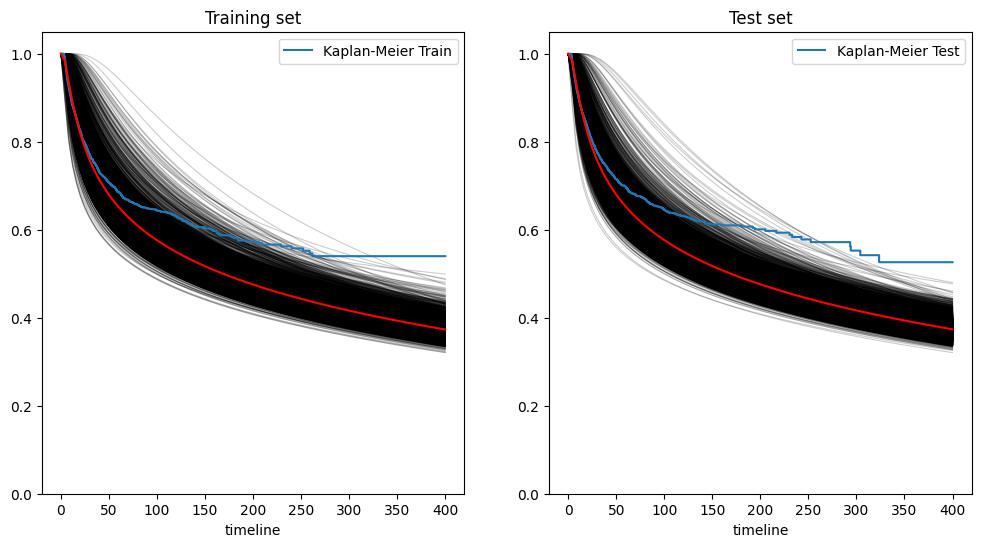

In [13]:
fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (12,6))
 
n_max = 5000
# n_max = S_ts_train_linear.shape[1]
train_idx = np.random.choice( np.arange(S_ts_train_linear.shape[1]), size = np.min([n_max, S_ts_train_linear.shape[1]]), replace = False )
test_idx = np.random.choice( np.arange(S_ts_test_linear.shape[1]), size = np.min([n_max, S_ts_test_linear.shape[1]]), replace = False )

utils.average_kaplan_meier(ts_grid,
                           S_ts_train_linear[:, train_idx], S_ts_test_linear[:, test_idx],
                           y_train[train_idx], delta_train[train_idx], y_test[test_idx], delta_test[test_idx], show_individual = True, ax1 = ax[0], ax2 = ax[1])
plt.show()